In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import os
import math
import diffsci.data
import diffsci.models
from scipy.stats import wasserstein_distance, entropy
import pathlib
import re
from scipy import integrate
import itertools

In [3]:
device_id = 0
os.environ['CUDA_VISIBLE_DEVICES'] = str(device_id)

## Datasets

Mean: -0.0019877501763403416
std: 0.4291481375694275
radius: 1.4


Text(0.5, 0, 'value')

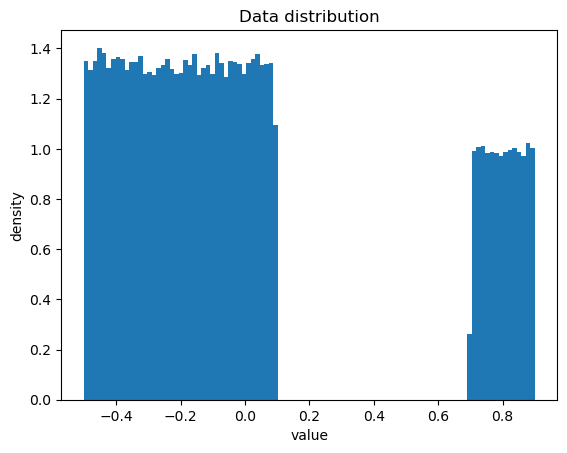

In [4]:
# Define the dataset
nsamples = 100000
intervals = [[-0.5, 0.1], [0.7, 0.9]]
weights = [0.8, 0.2]
uniform_dataset = diffsci.data.MixtureOf1DUniformsDataset(nsamples, intervals=intervals, weights=weights)
uniform_samples = uniform_dataset.sample()

# compute mean and std
mean = uniform_samples.mean()
std = uniform_samples.std()
radius = intervals[1][1] - intervals[0][0]
print(f'Mean: {mean}')
print(f'std: {std}')
print(f'radius: {radius}')


# Plot the sampled distribution
bins = 100
plt.hist(uniform_samples.squeeze(-1), bins=bins, density=True, label='data')
plt.title("Data distribution")
plt.ylabel("density")
plt.xlabel("value")

Mean: -0.009573541581630707
std: 0.3486485481262207


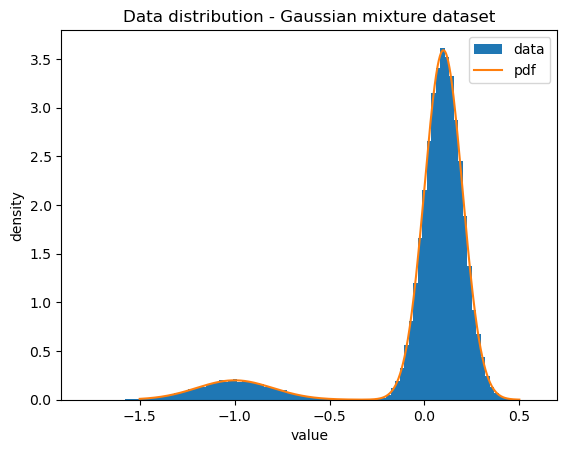

In [5]:
# Define Gaussian mixture dataset
points2 = torch.tensor([-1,0.1]).unsqueeze(-1)
weights2 = torch.tensor([0.1,0.9])
scale2 = torch.tensor([0.2,0.1])
nsamples2 = 100000
gaussian_dataset2 = diffsci.data.MixtureOfGaussiansDataset(num_samples=nsamples2, means=points2, weights=weights2, scale=scale2) 
gaussian_samples2 = gaussian_dataset2.sample()

# compute mean and std
mean = gaussian_samples2.mean()
std = gaussian_samples2.std()
print(f'Mean: {mean}')
print(f'std: {std}')

# Plot the sampled distribution
bins = 100
plt.hist(gaussian_samples2.squeeze(-1), bins=bins, density=True, label='data')
plt.title("Data distribution - Gaussian mixture dataset")
plt.ylabel("density")
plt.xlabel("value")

# plot pdf
x = torch.linspace(-1.5, 0.5, 1000).unsqueeze(-1)
sigma0 = torch.zeros_like(x[..., 0])
pdf2 = gaussian_dataset2.prob(x, sigma0)
plt.plot(x, pdf2, label='pdf')
plt.legend()

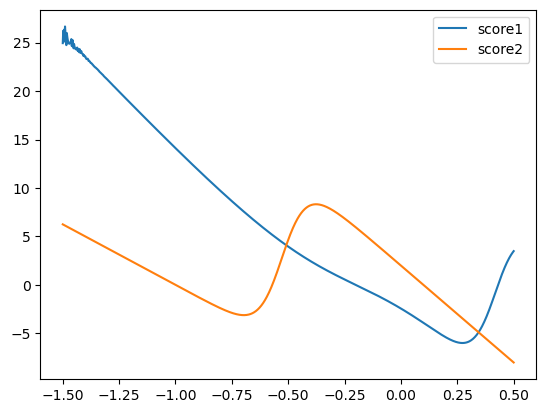

In [6]:
# plot score function
sigma = torch.ones_like(x[..., 0]) * 0.2
score1 = uniform_dataset.gradlogprob(x, sigma)
score2 = gaussian_dataset2.gradlogprob(x, sigma)
plt.plot(x, score1, label='score1')
plt.plot(x, score2, label='score2')
# plt.plot(x, 10*pdf, label='pdf1')
# plt.plot(x, 10*pdf2, label='pdf2')
plt.legend()

## Define all functions

In [57]:
# define diffusion prior
def prior_pdf(x, mean, sigma):
    expterm = -0.5 * (x - mean)**2 / sigma**2
    normalizer = 1/(np.sqrt(2*math.pi)*sigma)
    return normalizer * torch.exp(expterm)

# compute relative entropy for an aligned pair of densities (p, q) and a grid x
def relative_entropy(p, q, x, epsilon = 1e-15):
    # Avoid division by zero and log of zero
    p_values = torch.clip(p, epsilon, None)
    q_values = torch.clip(q, epsilon, None)

    x_size = abs(x[1] - x[0])
    dx = x_size.item()
    kl_divergence = torch.trapezoid(p_values * torch.log(p_values / q_values), dx=dx, dim=0)
    return kl_divergence

# standard way to format variables
def formatted(variable):
    if variable < 1e-3:
        formatted_variable = f'{variable:.2e}'
        formatted_variable = re.sub(r'e([-+]?)(\d+)', r' \\times 10^{\1\2}', formatted_variable)
    else:
        formatted_variable = f'{variable:.4f}'
    return formatted_variable

def analytical_initial_entropy(dataset, initial_time, scheduler = diffsci.models.EDMScheduler(),
                               xlim = 3, ngrid =10000, plot = False, return_pdf=False, data_label = 'MoG',
                               fontsize = 14, inverseH = False, ylim = None, prior_perturbation = None):
    sigma = scheduler.scheduler_fns.noise_fn(torch.tensor(initial_time))
    scale = scheduler.scheduler_fns.scaling_fn(torch.tensor(initial_time))
    s = torch.tensor(sigma*scale)
    x = torch.linspace(-xlim, xlim,ngrid)
    x_ = x.unsqueeze(-1)
    if prior_perturbation is not None:
        p = prior_pdf(x_, prior_perturbation[0], prior_perturbation[1]*s)
    else:
        p = prior_pdf(x_, s)
    q = dataset.prob(x_, sigma.unsqueeze(-1), scale.unsqueeze(-1))
    q = q.unsqueeze(-1)
    if inverseH:
        entropy = relative_entropy(q, p, x).item()
    else:
        entropy = relative_entropy(p, q, x).item()
    if plot:
        plt.plot(x, p, label='perturbed prior')
        plt.plot(x, q, label='exact prior')
        plt.ylabel('density', fontsize=fontsize)
        plt.legend(fontsize=fontsize)
        if ylim is not None:
            plt.ylim(0, ylim)
        plt.title(f'Distributions at $t = {initial_time:.2f}$ ({data_label})', fontsize=fontsize+4)
        
        # Add a text box
        formatted_entropy = formatted(entropy)
        if inverseH:
            textstr = f'$H(p|\~p) = {formatted_entropy}$'
        else:
            textstr = f'$H(\~p|p)$ value:\n$H_{{init}} = {formatted_entropy}$'
        plt.gca().text(0.025, 0.75, textstr, transform=plt.gca().transAxes, fontsize=fontsize,
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
        plt.show()
    if return_pdf:
        return entropy, p, q, x
    else:
        return entropy


def approx_entropy(samples1, samples2, samples_ref, epsilon=1e-12, nbins=100, mean = True,
                   inverseH = False):
    entropies1 = []
    entropies2 = []
    for nb in range(nbins-20, nbins):
        if nb%4 == 0:
            continue
        min_value = torch.min(torch.tensor([samples1.min(), samples2.min(), samples_ref.min()]))
        max_value = torch.max(torch.tensor([samples1.max(), samples2.max(), samples_ref.max()]))
        dist = []
        bins = np.linspace(min_value, max_value, nb)
        for samples in [samples1, samples2, samples_ref]:
            hist = np.histogram(samples, bins=bins, density=True)[0]
            dist.append(hist+epsilon)
        if inverseH:
            entropy1 = entropy(dist[2], dist[0])
            entropy2 = entropy(dist[2], dist[1])
        else:
            entropy1 = entropy(dist[0], dist[2])
            entropy2 = entropy(dist[1], dist[2])
        entropies1.append(entropy1)
        entropies2.append(entropy2)
    if mean:
        entropy1 = np.mean(entropies1)
        entropy2 = np.mean(entropies2)
    else:
        entropy1 = np.min(entropies1)
        entropy2 = np.min(entropies2)
    return entropy1, entropy2

def approx_entropy1(samples, samples_ref, epsilon=1e-12, nbins=100):
    min_value = torch.min(torch.tensor([samples.min(), samples_ref.min()]))
    max_value = torch.max(torch.tensor([samples.max(), samples_ref.max()]))
    entropies = []
    for nb in range(nbins-20, nbins):
        if nb % 4 == 0:
            continue
        bins = np.linspace(min_value, max_value, nb)
        dist = []
        for s in [samples, samples_ref]:
            hist = np.histogram(s, bins=bins, density=True)[0]
            dist.append(hist+epsilon)
        entropies.append(entropy(dist[0], dist[1]))
    return np.mean(entropies)


def generate_samples(initial_step, gamma, nsteps, nsamples, dataset,
                     interval=None,
                     sample_type='ode',
                     noisescheduler=diffsci.models.EDMScheduler(),
                     scheduler_type= 'edm',
                     module=None,
                     use_exact_prior=False,
                     return_history=True,
                     checkpoint=None,
                     save_samples=False,
                     interp_fn = None,
                     prior_perturbation = None):        # [mean, std]
    print(f'NoiseScheduler: {noisescheduler}')
    # set noise scheduler
    noisescheduler._integrator = diffsci.models.EulerIntegrator()
    noisescheduler.langevin_const = gamma
    noisescheduler.langevin_interval = interval
    if module is not None:
        module.config.noisescheduler = noisescheduler
    
    # obtain initial time from initial step
    time = noisescheduler.create_steps(nsteps+1)
    initial_time_ = time[initial_step]
    initial_time = initial_time_.item() 

    # generate prior distribution
    dataset.num_samples = nsamples
    samples = dataset.sample()
    sigma = noisescheduler.scheduler_fns.noise_fn(initial_time_)
    scale = noisescheduler.scheduler_fns.scaling_fn(initial_time_)
    prior = torch.randn_like(samples) * sigma * scale
    if prior_perturbation is not None:
        prior = prior * prior_perturbation[1] + prior_perturbation[0]
    prior_ = prior.squeeze(-1)
    exact_prior = noisescheduler.apply_noise(samples, nsteps, initial_step)
    exact_prior_ = exact_prior.squeeze(-1)

    # plot prior distributions
    nbins = 100
    xlim = 5*sigma
    exact_initial_entropy, approx_dens, exact_dens, x = analytical_initial_entropy(
        dataset, initial_time, scheduler=noisescheduler, plot = False, return_pdf=True,
        xlim=xlim, prior_perturbation=prior_perturbation)
    print(f'Exact initial divergence = {exact_initial_entropy:.5f}')

    fig, ax = plt.subplots(1,2,figsize=(12,5))
    ax[0].hist(prior_, bins=nbins, density=True, alpha=0.5, label='current prior', color='brown')
    ax[0].hist(exact_prior_, bins=nbins, density=True, alpha=0.5, color='green', label='exact prior')
    ax[0].set_title(f'Samples at time T={initial_time:.2f}')
    ax[0].xlim = xlim
    ax[0].legend()
    ax[1].plot(x, exact_dens, label='exact prior pdf')
    ax[1].plot(x, approx_dens, label='current prior pdf')
    ax[1].set_title(f'Densities at time T={initial_time:.2f}')
    ax[1].legend()
    # text box
    formatted_intial_entropy = formatted(exact_initial_entropy)
    textstr = f'Entropy value:\n$H_{{init}} = {formatted_intial_entropy}$'
    ax[1].text(0.025, 0.95, textstr, transform=ax[1].transAxes, fontsize=12,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
    plt.show()

    # backward integration
    if use_exact_prior:
        prior = exact_prior
    
    if sample_type == 'ode':
        stochastic = False
        integrator = diffsci.models.EulerIntegrator()
    elif sample_type == 'sde':
        stochastic = True
        integrator = diffsci.models.EulerMaruyamaIntegrator()
    else:
        raise ValueError('Invalid sample_type')
    
    if module is not None:
        print('Sampling with learned scores, device: ', module.device)
        prior = prior.to(module.device)
        sample_history = module.propagate_partial_toward_sample(
             prior, initial_step=initial_step, nsteps=nsteps, record_history=True, integrator=integrator,
             analytical_score=dataset.gradlogprob, interp_fn=interp_fn)
        sample_history = sample_history.cpu()
    else:
        sample_history = noisescheduler.propagate_partial(
            prior, dataset.gradlogprob, nsteps, initial_step=initial_step, final_step=nsteps,
            record_history=True, stochastic=stochastic)
    
    # plot trajectory
    time = noisescheduler.create_steps(nsteps+1)
    trunc_time = time[initial_step:]
    nplot = 300
    fig = plt.figure(figsize=(8, 6))
    for i in range(nplot):
        x = sample_history[:, i].squeeze()
        plt.plot(trunc_time, x, color='black', linestyle='-', alpha=0.1)
    plt.xlabel("diffusion time", fontsize=14)
    plt.ylabel("value", fontsize=14)
    # plt.xlim([0, 1])
    plt.ylim([-300, 300])
    if sample_type == 'ode':
        plt.title(f'ODE trajectories ({scheduler_type.upper()})', fontsize=16)
    else:
        plt.title(f'SDE trajectories ($\gamma = {gamma}$)', fontsize=16)
    plt.show()

    if return_history:
        samples = sample_history.squeeze(-1)
    else:
        samples = sample_history[-1].squeeze(-1)

    # save data
    if save_samples:
        if module is not None:
            if checkpoint is None:
                raise ValueError('Checkpoint is required')
            path = pathlib.Path(checkpoint).parent.parent / 'saved_samples'
        else:
            raise ValueError('Module is required')
        path.mkdir(exist_ok=True)
        
        filename = f'nsamples={nsamples:.0e}-nsteps={nsteps}-T={initial_time:.3f}'
        if module is not None:
            filename = 'tr-' + filename
        else:
            filename = 'an-' + filename
        if use_exact_prior:
            filename = f'{sample_type}-exact_prior-' + filename
        else:
            filename = f'{sample_type}-indep_prior-' + filename
        if sample_type == 'sde':
            if interval is not None:
                filename += f'-g={gamma}-int={interval}'
            else:
                filename += f'-g={gamma}'
        if interp_fn is not None:
            filename += '-interp'
        
        if return_history:
            filename += '-his'            
        if scheduler_type == 'edm':
            filename += '-EDM'
        elif scheduler_type == 'vp':
            filename += '-VP'
        elif scheduler_type == 've':
            filename += '-VE'
        else:
            raise ValueError('Invalid scheduler_type')
        
        print(f'Saving samples to {path / filename}')
        torch.save(samples, path / filename)
    return samples


def plot_figure(samples_ode, samples_sde, diffused_data, gamma, datatype,
                initial_entropy=None, bound=None, nbins=100, title='Approximate prior and analytic scores',
                fontsize=14, ylim=4):
    # compute entropy
    ode_entropy, sde_entropy = approx_entropy(samples_ode, samples_sde, diffused_data, nbins=nbins)

    # plot
    fig = plt.figure(figsize=(8, 6))
    plt.hist(samples_ode, bins=nbins, density=True, alpha=0.5, label='ODE')
    plt.hist(samples_sde, bins=nbins, density=True, alpha=0.5, label=f'SDE ($\\gamma = {gamma:.1f}$)')
    plt.hist(diffused_data, bins=nbins, density=True, histtype='step', color='black', label='data')
    plt.ylabel("density", fontsize=fontsize)
    plt.ylim(0, ylim)
    if datatype == 'uniform':
        plt.legend(fontsize=fontsize, loc='upper center', bbox_to_anchor=(0.585, 1.0))
        text_position = (0.1, 0.96)
    else:
        plt.legend(fontsize=fontsize)
        text_position = (0.03, 0.69)
    plt.title(title, fontsize=fontsize+4)

    # Add a text box
    if initial_entropy is not None:
        formatted_initial_entropy = formatted(initial_entropy)
        textstr = f'$H(\~p|p)$ values:\n$H_{{init}} = {formatted_initial_entropy}$ \n$H_{{ODE}} = {ode_entropy:.4f}$ \n$H_{{SDE}} = {sde_entropy:.4f}$ \n ($n_{{bins}} = {nbins}$)'
    else:
        textstr = f'$H(\~p|p)$ values:\n$H_{{ODE}} = {ode_entropy:.4f}$ \n$H_{{SDE}} = {sde_entropy:.4f}$ \n ($n_{{bins}} = {nbins}$)'
    if bound is not None:
        textstr += f'\n \n bound: {bound:.4f}'
    plt.gca().text(text_position[0], text_position[1], textstr, transform=plt.gca().transAxes, fontsize=fontsize,
                   verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))


def compute_entropy_evolution(ode_history, sde_history, diffused_history, time,  mean=True, nbins=100,
                              inverseH=False):

    ode_entropies = []
    sde_entropies = []
    ode_wdistances = []
    sde_wdistances = []
    nsteps = time.shape[0]
    for i in range(nsteps):
        ode_entropy, sde_entropy = approx_entropy(ode_history[i], sde_history[i], diffused_history[i],
                                                  nbins=nbins, mean=mean, inverseH=inverseH)
        ode_entropies.append(ode_entropy)
        sde_entropies.append(sde_entropy)
    return ode_entropies, sde_entropies

def plot_entropy_evolution(ode_entropies, sde_entropies, time, gamma, initial_time,
                           initial_entropy=None, bound_history=None, nbins=100,
                           title='approximate prior and analytic scores',
                           x_logscale=False, y_logscale=False, ylim=None, fontsize=14):
    
    fig = plt.figure(figsize=(8, 6))
    plt.plot(time, ode_entropies, label='ODE')
    plt.plot(time, sde_entropies, label=f'SDE ($\\gamma = {gamma:.1f}$)')
    if bound_history is not None:
        plt.plot(time, bound_history, label='bound (SDE)', linestyle='--')
    plt.hlines(initial_entropy, 0, initial_time, label='initial', linestyle='-.')
    plt.xlabel("diffusion time", fontsize=fontsize)
    plt.ylabel(f"divergence values ($n_{{bins}}={nbins}$)", fontsize=fontsize)
    if x_logscale:
        plt.xscale('log')
    if y_logscale:
        plt.yscale('log')
    if ylim is not None:
        plt.ylim(0, ylim)
    plt.legend(fontsize=fontsize)
    plt.title('KL divergence evolution,'+ title,fontsize=fontsize+2)
    plt.tight_layout()


def plot_entropy_evolution2(sde_entropy1, sde_entropy2, label1, label2, time, gamma, initial_time,
                            bound_history1=None, bound_history2=None, initial_entropy=None,
                            nbins=100, entropy_name='$H(\~p|p)$', x_logscale=False, y_logscale=False, ylim=None,
                            colors=['green', 'blue', 'orange']):
    
    fig = plt.figure(figsize=(6, 5))
    plt.plot(time, sde_entropy1, label=label1, color=colors[0], alpha=0.7)
    plt.plot(time, sde_entropy2, label=label2, color=colors[1], alpha=0.7)
    if bound_history1 is not None:
        plt.plot(time, bound_history1, label=f'bound ({label1})', linestyle='--', color=colors[0], alpha=0.7)
    if bound_history2 is not None:
        plt.plot(time, bound_history2, label=f'bound ({label2})', linestyle='--', color=colors[1], alpha=0.7)
    plt.hlines(initial_entropy, 0, initial_time, label='initial/ ODE', linestyle='-.', color=colors[2], alpha=0.7)
    plt.xlabel("diffusion time", fontsize=14)
    plt.ylabel(entropy_name + f' ($n_{{bins}}={nbins}$)', fontsize=14)
    if x_logscale:
        plt.xscale('log')
    if y_logscale:
        plt.yscale('log')
    if ylim is not None:
        plt.ylim(0, ylim)
    plt.legend(fontsize=12, loc='lower right')
    plt.title('Evolution of ' + entropy_name + f' ($\gamma={gamma}$)',fontsize=16)
    plt.tight_layout()


def custom_spacing(min, max, N, alpha):
    min_alpha = min ** alpha
    max_alpha = max ** alpha
    lin_space = torch.linspace(min_alpha, max_alpha, N)
    gamma_values = lin_space ** (1 / alpha)
    return gamma_values

def generate_multiple_gamma(initial_step, gamma_range, nsteps, nsamples, dataset,
                            ngamma=20,
                            interval=None,
                            noisescheduler=diffsci.models.EDMScheduler(sigma_max=10),
                            module=None,
                            use_exact_prior=False,
                            return_history=True,
                            alpha=0.5,
                            prior_perturbation=None):
    # set noise scheduler
    noisescheduler._integrator = diffsci.models.EulerIntegrator()
    noisescheduler.langevin_interval = interval
    if module is not None:
        module.config.noisescheduler = noisescheduler
    
    # hack to obtain step from initial_time
    time = noisescheduler.create_steps(nsteps+1)
    initial_time = time[initial_step].item()


    # generate prior distributions
    dataset.num_samples = nsamples
    samples = dataset.sample()
    sigma = noisescheduler.scheduler_fns.noise_fn(initial_time)
    scale = noisescheduler.scheduler_fns.scaling_fn(initial_time)
    prior = torch.randn_like(samples) * sigma * scale
    if prior_perturbation is not None:
        prior = prior * prior_perturbation[1] + prior_perturbation[0]
    exact_prior = noisescheduler.apply_noise(samples, nsteps, initial_step)

    # backward integration
    if use_exact_prior:
        prior = exact_prior
    
    assert len(gamma_range) == 2
    gamma_values = custom_spacing(gamma_range[0], gamma_range[-1], ngamma, alpha)
    # print(f'Gamma values: {gamma_values}')

    if module is not None:
        prior = prior.to(module.device)
        ode_sample_history = module.propagate_partial_toward_sample(prior, initial_step=initial_step, nsteps=nsteps,
                                                                    record_history=True,
                                                                    integrator=diffsci.models.EulerIntegrator())
        ode_sample_history = ode_sample_history.cpu()
        sde_sample_history_ = []
        for g in gamma_values:
            noisescheduler.langevin_const = g
            sde_sample_history = module.propagate_partial_toward_sample(prior, initial_step=initial_step, nsteps=nsteps,
                                                                        record_history=True,
                                                                        integrator=diffsci.models.EulerMaruyamaIntegrator())
            sde_sample_history_.append(sde_sample_history.cpu())
    else:
        ode_sample_history = noisescheduler.propagate_partial(prior, dataset.gradlogprob, nsteps, initial_step=initial_step,
                                                              final_step=nsteps, record_history=True, stochastic=False)
        sde_sample_history_ = []
        for g in gamma_values:
            noisescheduler.langevin_const = g
            sde_sample_history = noisescheduler.propagate_partial(prior, dataset.gradlogprob, nsteps, initial_step=initial_step,
                                                                  final_step=nsteps, record_history=True, stochastic=True)
            sde_sample_history_.append(sde_sample_history)
    
    if return_history:
        ode_samples = ode_sample_history
        sde_samples = sde_sample_history_
    else:
        ode_samples = ode_sample_history[-1].squeeze(-1)
        sde_samples = [sde_sample_history[-1].squeeze(-1) for sde_sample_history in sde_sample_history_]
    samples = [ode_samples, sde_samples]
    return samples


def plot_multiple_gamma(samples, diffused_data, gamma_range, initial_time, nsteps, ngamma=20,
                        initial_entropy=None, nbins=100, title='Approximate prior and analytic scores'):
    
    # compute entropy
    assert len(gamma_range) == 2
    gamma_values = torch.linspace(gamma_range[0], gamma_range[-1], ngamma)
    ode_samples, sde_samples = samples

    ode_entropy = approx_entropy1(ode_samples, diffused_data, nbins=nbins)
    sde_entropies = []
    for sde_sample in sde_samples:
        sde_entropy = approx_entropy1(sde_sample, diffused_data, nbins=nbins)
        sde_entropies.append(sde_entropy)

    # plot
    fig = plt.figure(figsize=(8, 6))
    plt.plot(gamma_values, sde_entropies, label='$H_{SDE}$')
    plt.hlines(ode_entropy, gamma_range[0], gamma_range[-1], label='$H_{ODE}$', linestyle='-.')
    if initial_entropy is not None:
        plt.hlines(initial_entropy, gamma_range[0], gamma_range[-1], label='initial entropy', linestyle='--')
        max_entropy = max(initial_entropy, ode_entropy)
    else:
        max_entropy = ode_entropy
        
    plt.xlabel("$\gamma$")
    plt.ylabel(f"entropy values \n $n_{{bins}}={nbins}$")
    plt.ylim(0, 2*max_entropy)
    plt.legend()
    plt.title(title + f', $T={initial_time:.2f}$, $nsteps={nsteps}$')


def plot_multiple_gamma2(data: list,
                        diffused_data,
                        initial_entropy=None, nbins=100, alpha=0.5,
                        xlim=None, ylim=None, plot_scaling=True,
                        title='Approximate prior and analytic scores',
                        fontsize=14):

    if plot_scaling:
        fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    else:
        fig, axs = plt.subplots(1, 1, figsize=(6, 4))
    max_entropy = 0
    gamma_max = 0
    gamma_min = 1e10
    scaled_gamma_max = 0
    scaled_gamma_min = 1e10
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'olive', 'cyan']

    for i, item in enumerate(data):
        samples, gamma_range, ngamma, nsteps = item
        ode_samples, sde_samples = samples
        # compute entropy
        assert len(gamma_range) == 2
        gamma_values = custom_spacing(gamma_range[0], gamma_range[-1], ngamma, alpha)

        # ode_entropy = approx_entropy1(ode_samples, diffused_data, nbins=nbins)
        sde_entropies = []
        for sde_sample in sde_samples:
            sde_entropy = approx_entropy1(sde_sample, diffused_data, nbins=nbins)
            sde_entropies.append(sde_entropy)
        
        scaled_gamma = gamma_values / nsteps
        if plot_scaling:
            axs[0].plot(gamma_values, sde_entropies, label=f'$H_{{SDE}}$, $n_{{steps}}={nsteps}$', alpha=0.8, color=colors[i])
            axs[1].plot(scaled_gamma, sde_entropies, label=f'$H_{{SDE}}$, $n_{{steps}}={nsteps}$', alpha=0.8, color=colors[i])
        else:
            axs.plot(gamma_values, sde_entropies, label=f'$H_{{SDE}}$, $n_{{steps}}={nsteps}$', alpha=0.8)
        gamma_max = max(gamma_max, gamma_range[-1])
        gamma_min = min(gamma_min, gamma_range[0])
        scaled_gamma_max = max(scaled_gamma_max, scaled_gamma[-1])
        scaled_gamma_min = min(scaled_gamma_min, scaled_gamma[0])
        
    if initial_entropy is not None:
        if plot_scaling:
            axs[0].hlines(initial_entropy, gamma_min, gamma_max, label='initial divergence', linestyle='--', color='gray', alpha=0.8)
            axs[1].hlines(initial_entropy, scaled_gamma_min, scaled_gamma_max, label='initial divergence', linestyle='--', color='gray', alpha=0.8)
        else:
            axs.hlines(initial_entropy, gamma_min, gamma_max, label='initial divergence', linestyle='--')
        
    if plot_scaling:
        axs[0].set_xlabel("$\gamma$", fontsize=fontsize)
        axs[1].set_xlabel("$\gamma/n_{steps}$", fontsize=fontsize)
        for ax in axs:
            if ylim is not None:
                ax.set_ylim(0, ylim)
            else:
                ax.set_ylim(0, 1.5*initial_entropy)
        if xlim is not None:
            axs[0].set_xlim(0, xlim)
            axs[1].set_xlim(0, xlim/1000)
        fig.suptitle(title, fontsize=fontsize+6)
        fig.subplots_adjust(top=0.8)
        axs[0].set_title('Unscaled x-axis', fontsize=fontsize+2)
        axs[1].set_title('Scaled x-axis', fontsize=fontsize+2)
        axs[0].set_ylabel(f"$H(\~p|p)$ values ($n_{{bins}}={nbins}$)", fontsize=fontsize)
        axs[1].legend(fontsize=fontsize, loc='center left', bbox_to_anchor=(1, 0.5))
    else:
        axs.set_xlabel("$\gamma$", fontsize=fontsize)
        axs.set_ylabel(f"$H(\~p|p)$ values ($n_{{bins}}={nbins}$)", fontsize=fontsize)
        if ylim is not None:
            axs.set_ylim(0, ylim)
        else:
            axs.set_ylim(0, 1.5*initial_entropy)
            if xlim is not None:
                axs.set_xlim(0, xlim)
        axs.legend(fontsize=fontsize)
        axs.set_title(title, fontsize=fontsize+4)


# compute theorectical bound for the Gaussian mixture dataset

def c_gauss(t, m, p, sigma_data):           # this 't' is the forward time, which is in the following denoted by rev_t
    sigma = scheduler.scheduler_fns.noise_fn(torch.tensor(t))
    scale = scheduler.scheduler_fns.scaling_fn(torch.tensor(t))
    sigma2 = scale**2 * (sigma**2 + sigma_data**2)
    lamb = (np.log(p) - np.log(1 - p))/(2*p - 1)
    m2 = (scale * m)**2
    c = sigma2 * (1 + (p*(1 - p) * lamb * (np.exp(m2/sigma2) + 1)))
    return c


def c_gauss2(t, m, p, sigma_data):           # this 't' is the forward time, which is in the following denoted by rev_t
    sigma = scheduler.scheduler_fns.noise_fn(torch.tensor(t))
    scale = scheduler.scheduler_fns.scaling_fn(torch.tensor(t))
    sigma_0, sigma_1 = sigma_data
    sigma_0 = scale * np.sqrt(sigma**2 + sigma_0**2)
    sigma_1 = scale * np.sqrt(sigma**2 + sigma_1**2)
    m2 = (scale * m)**2
    # chi_0 = chi^2(mu_0 || mu_1) + 1, finite iff 2*sigma_1^2 > sigma_0^2
    if 2*sigma_1**2 - sigma_0**2 > 0:
        chi_0 = sigma_1**2/(sigma_0 * np.sqrt(2*sigma_1**2 - sigma_0**2)) * np.exp(m2/(2*sigma_1**2 - sigma_0**2))
    else:
        chi_0 = float('inf')
    # chi_1 = chi^2(mu_1 || mu_0) + 1, finite iff 2*sigma_0^2 > sigma_1^2
    if 2*sigma_0**2 - sigma_1**2 > 0:
        chi_1 = sigma_0**2/(sigma_1 * np.sqrt(2*sigma_0**2 - sigma_1**2)) * np.exp(m2/(2*sigma_0**2 - sigma_1**2))
    else:
        chi_1 = float('inf')
    if p == 0.5:
        lamb = 2
    else:
        lamb = (np.log(p) - np.log(1 - p))/(2*p - 1)
    # Schlichting (2019), Corollary 2:
    #   Case mu_0 << mu_1 (finite chi_0)
    c_0 = max(sigma_0**2 * (1 + (1-p)*lamb), sigma_1**2 * (1 + p*lamb*chi_0))
    #   Case mu_1 << mu_0 (finite chi_1)
    c_1 = max(sigma_1**2 * (1 + p*lamb),     sigma_0**2 * (1 + (1-p)*lamb*chi_1))
    c = min(c_0, c_1)
    return c

def c_uniform(t, radius):
    sigma = scheduler.scheduler_fns.noise_fn(torch.tensor(t))
    exp = torch.exp(4*radius**2/sigma**2)
    return 6*(4*radius**2+sigma**2)*exp

def integrand(t, initial_time, m, p, sigma_data, radius):
    rev_t = initial_time - t
    if process == 'edm':
        g2 = 2*rev_t
    elif process == 'vp':
        beta_min = 0.1
        beta_d = 19.9
        g2 = beta_d * rev_t + beta_min
    elif process == 've':
        g2 = 1
    if datatype == 'gaussian':
        c = c_gauss(rev_t, m, p, sigma_data)
    elif datatype == 'gaussian2':
        c = c_gauss2(rev_t, m, p, sigma_data)
    elif datatype == 'uniform':
        c = c_uniform(rev_t, radius)
    return 1/c * gamma * g2

def compute_integral(t_initial, t_final, initial_time, m=None, p=None, sigma_data=None, radius=None):
    result, error = integrate.quad(
        integrand, t_initial, t_final, args=(initial_time, m, p, sigma_data, radius))
    return result, error

<>:57: SyntaxWarning: invalid escape sequence '\~'
<>:59: SyntaxWarning: invalid escape sequence '\~'
<>:217: SyntaxWarning: invalid escape sequence '\g'
<>:292: SyntaxWarning: invalid escape sequence '\~'
<>:294: SyntaxWarning: invalid escape sequence '\~'
<>:342: SyntaxWarning: invalid escape sequence '\~'
<>:362: SyntaxWarning: invalid escape sequence '\g'
<>:468: SyntaxWarning: invalid escape sequence '\g'
<>:525: SyntaxWarning: invalid escape sequence '\g'
<>:526: SyntaxWarning: invalid escape sequence '\g'
<>:539: SyntaxWarning: invalid escape sequence '\~'
<>:542: SyntaxWarning: invalid escape sequence '\g'
<>:543: SyntaxWarning: invalid escape sequence '\~'
<>:57: SyntaxWarning: invalid escape sequence '\~'
<>:59: SyntaxWarning: invalid escape sequence '\~'
<>:217: SyntaxWarning: invalid escape sequence '\g'
<>:292: SyntaxWarning: invalid escape sequence '\~'
<>:294: SyntaxWarning: invalid escape sequence '\~'
<>:342: SyntaxWarning: invalid escape sequence '\~'
<>:362: SyntaxWa

In [28]:
# create Scheduler class with EDM steps
class VEScheduler(diffsci.models.VEScheduler):
    def __init__(self,
                 sigma_min: float = 0.002,
                 sigma_max: float = 100,
                 expoent_steps: float = 7.0,
                 scheduler_fns = "VE",
                 *args,
                 **kwargs):
        super().__init__(sigma_min,
                         sigma_max,
                         scheduler_fns,
                         *args,
                         **kwargs)
        self._integrator = diffsci.models.EulerIntegrator()
        self.register_buffer("expoent_steps", torch.tensor(expoent_steps))
    
    def create_steps(self, n: int):
        s = torch.arange(n).to(self.expoent_steps)/(n-1)
        start = self.sigma_max**(1/self.expoent_steps)
        end = self.sigma_min**(1/self.expoent_steps)
        steps = (start + s*(end - start))**(self.expoent_steps)
        if not self.scheduler_fns.identity_noise_fn:
            steps = self.scheduler_fns.inverse_noise_fn(steps)
        return steps

    def step_from_time(self, t, n: int):
        exp = 1/self.expoent_steps
        sigma = self.scheduler_fns.noise_fn(t)
        step = (n-1) * (sigma**(exp) - self.sigma_max**(exp)) / (self.sigma_min**(exp) - self.sigma_max**(exp))
        return torch.round(step).int()


class VPScheduler(diffsci.models.VPScheduler):
    def __init__(self,
                 epsilon_min: float = 0.001,
                 expoent_steps: float = 7.0,
                 sigma_min: float = 0.002,
                 sigma_max: float = 10.0,
                 scheduler_fns = "VP",
                 *args,
                 **kwargs):
        super().__init__(epsilon_min,
                         scheduler_fns,
                         *args,
                         **kwargs)
        self._integrator = diffsci.models.EulerIntegrator()
        self.register_buffer("expoent_steps", torch.tensor(expoent_steps))
        self.register_buffer("sigma_min", torch.tensor(sigma_min))
        self.register_buffer("sigma_max", torch.tensor(sigma_max))
    
    def create_steps(self, n: int):
        s = torch.arange(n).to(self.expoent_steps)/(n-1)
        start = self.sigma_max**(1/self.expoent_steps)
        end = self.sigma_min**(1/self.expoent_steps)
        steps = (start + s*(end - start))**(self.expoent_steps)
        if not self.scheduler_fns.identity_noise_fn:
            steps = self.scheduler_fns.inverse_noise_fn(steps)
        return steps

    def step_from_time(self, t, n: int):
        exp = 1/self.expoent_steps
        sigma = self.scheduler_fns.noise_fn(t)
        step = (n-1) * (sigma**(exp) - self.sigma_max**(exp)) / (self.sigma_min**(exp) - self.sigma_max**(exp))
        return torch.round(step).int()

## Analytical score functions

In [29]:
# Parameters for sampling
process = 'edm'

if process == 'edm':
    scheduler = diffsci.models.EDMScheduler()
    initial_time=80
    # scheduler = diffsci.models.EDMScheduler(sigma_max=10.0)
    # initial_time=0.75
elif process == 'vp':
    # scheduler = VPScheduler(sigma_max=20)
    scheduler = VPScheduler()
    initial_time=0.21
elif process == 've':
    scheduler = VEScheduler()
    initial_time=0.55
else:
    raise ValueError('Invalid process')

initial_time_ = torch.tensor(initial_time)
nsteps = 500
gamma = 1
nsamples = 100000
prior_perturbation = [50, 1.5]

initial_step = scheduler.step_from_time(t=initial_time_, n=nsteps)
time = scheduler.create_steps(nsteps+1)
initial_time = time[initial_step].item()
print(f'Initial step: {initial_step}')
print(f'Initial_time: {initial_time}')

Initial step: 0
Initial_time: 80.00001525878906


In [30]:
# # Generate data for comparison
tmin = time[-1]
print(f'Final time: {tmin}')
sigma_min = scheduler.scheduler_fns.noise_fn(tmin)
scale_min = scheduler.scheduler_fns.scaling_fn(tmin)
noise = torch.randn_like(uniform_samples) * sigma_min * scale_min

diffused_uniform_data = scale_min * uniform_samples + noise
diffused_uniform_data = diffused_uniform_data.squeeze(-1)
diffused_gaussian_data = scale_min * gaussian_samples2 + noise
diffused_gaussian_data = diffused_gaussian_data.squeeze(-1)

Final time: 0.0


In [50]:
# Parameters for the dataset
datatype = 'uniform'

sigma = scheduler.scheduler_fns.noise_fn(initial_time_)
if datatype == 'gaussian':
    diffused_data = diffused_gaussian_data
    dataset = gaussian_dataset2
    datatype = 'gaussian2'
    data = gaussian_samples2
    xlim = 6*sigma
    data_label = 'MoG'
    
elif datatype == 'uniform':
    diffused_data = diffused_uniform_data
    dataset = uniform_dataset
    data = uniform_samples
    xlim = 5*sigma
    data_label = 'MoU'
else:
    raise ValueError('Invalid datatype')

/tmp/ipykernel_185035/1499965301.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  s = torch.tensor(sigma*scale)


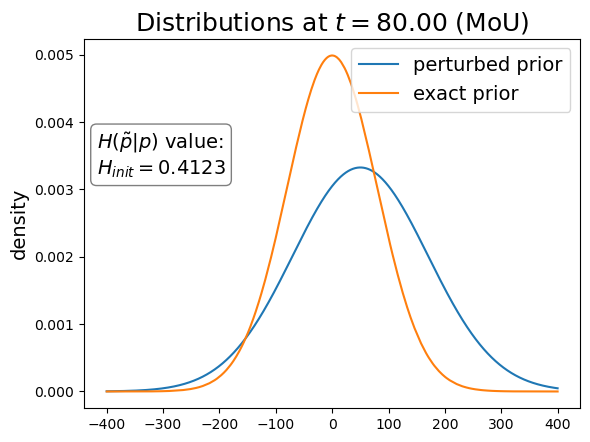

In [51]:
exact_initial_entropy = analytical_initial_entropy(dataset, initial_time, scheduler=scheduler, plot=True, xlim=xlim.item(), data_label=data_label,
                                                   fontsize=14, prior_perturbation=prior_perturbation)

In [52]:
# data parameters
m = abs(points2[0] - points2[1])
p = weights2[0]
sigma_data = [scale2[0], scale2[1]]
radius = intervals[1][1] - intervals[0][0]

# compute bound
integral, error = compute_integral(0, initial_time-tmin, initial_time, m, p, sigma_data, radius)
decay= np.exp(-integral)
bound = decay * exact_initial_entropy
print(f'initial divergence: {exact_initial_entropy:.7f}')
print(f'Bound: {bound:.7f}')

initial divergence: 0.4122598
Bound: 0.1639187


/tmp/ipykernel_185035/1499965301.py:598: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sigma = scheduler.scheduler_fns.noise_fn(torch.tensor(t))
/tmp/ipykernel_185035/1499965301.py:569: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sigma = scheduler.scheduler_fns.noise_fn(torch.tensor(t))
/tmp/ipykernel_185035/1499965301.py:570: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scale = scheduler.scheduler_fns.scaling_fn(torch.tensor(t))
/tmp/ipykernel_185035/1499965301.py:572: DeprecationWarning: __array_wrap__ must accept context and return_

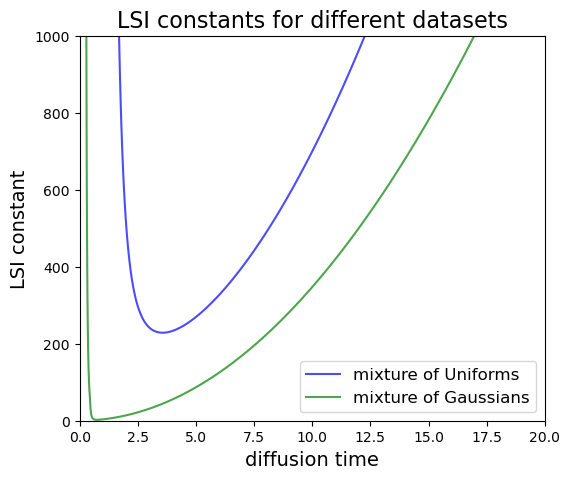

In [53]:
# plot LSI constants
c_uniforms = []
c_gauss2s = []
for t in time:
    c_u = c_uniform(t, radius).item()
    c_g = c_gauss2(t, m, p, sigma_data).item()
    if c_u > 1e6 or c_u==float('inf'):
        c_u = 1e6
    if c_g > 1e6 or c_g==float('inf'):
        c_g = 1e6
    c_uniforms.append(c_u)
    c_gauss2s.append(c_g)


fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(time, c_uniforms, label='mixture of Uniforms', color='blue', alpha=0.7)
ax.plot(time, c_gauss2s, label='mixture of Gaussians', color='green', alpha=0.7)
ax.set_xlabel('diffusion time', fontsize=14)
ax.set_ylabel('LSI constant', fontsize=14)
ax.set_xlim(time[-1], time[0])
ax.set_ylim(0, 1000)
ax.set_xlim(0, 20)
ax.legend(fontsize=12)
ax.set_title('LSI constants for different datasets', fontsize=16)
plt.show()

NoiseScheduler: EDMScheduler(
  (scheduler_fns): EDMSchedulingFunctions()
  (_integrator): EulerIntegrator()
  (stochastic_integrator): EulerMaruyamaIntegrator()
)
Exact initial divergence = 0.41226


/tmp/ipykernel_185035/1499965301.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  s = torch.tensor(sigma*scale)


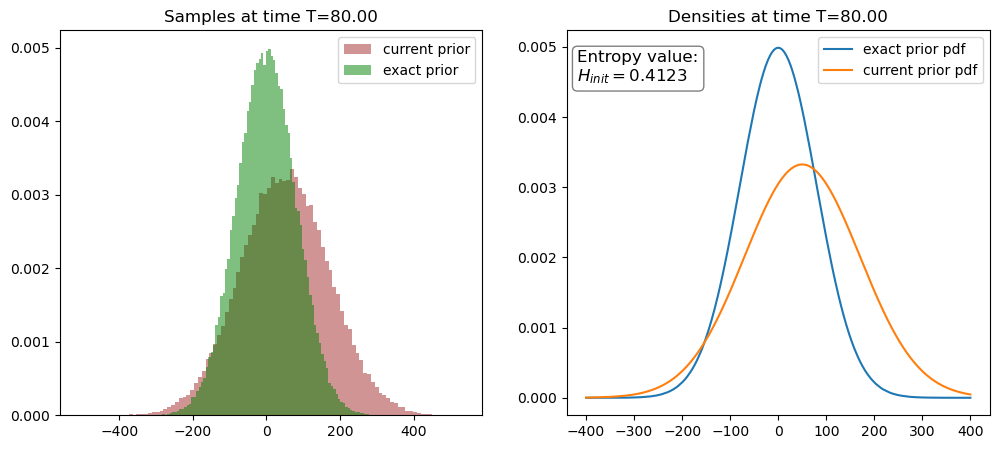

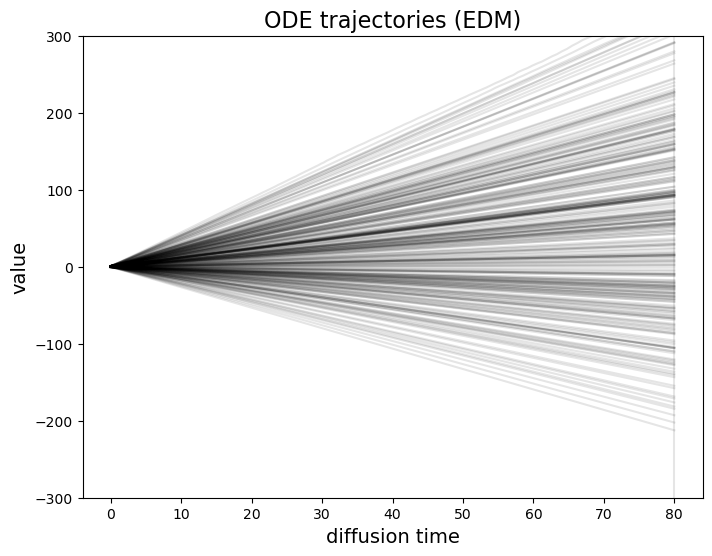

In [ ]:
ode_history = generate_samples(initial_step, gamma, nsteps, nsamples, dataset, sample_type='ode',
                               noisescheduler=scheduler, scheduler_type = process,
                               prior_perturbation=prior_perturbation)

NoiseScheduler: EDMScheduler(
  (scheduler_fns): EDMSchedulingFunctions()
  (_integrator): EulerIntegrator()
  (stochastic_integrator): EulerMaruyamaIntegrator()
)
Exact initial divergence = 0.41226


/tmp/ipykernel_185035/1499965301.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  s = torch.tensor(sigma*scale)


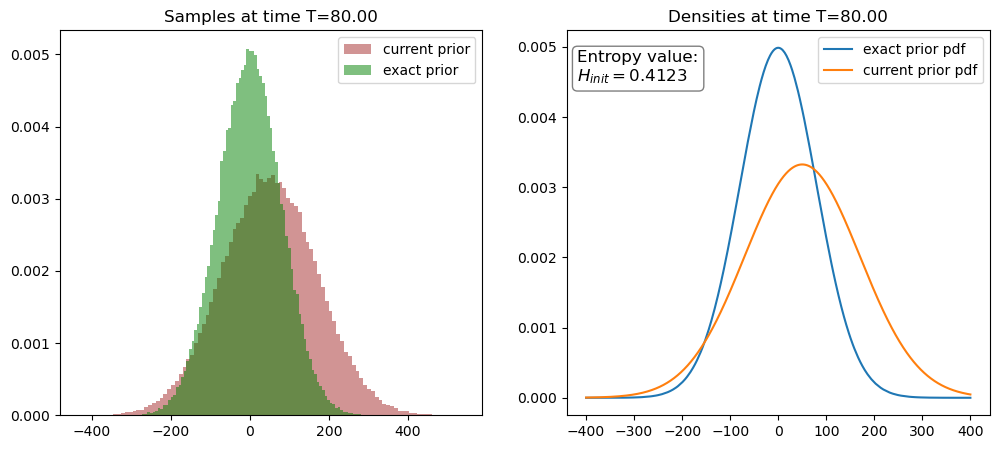

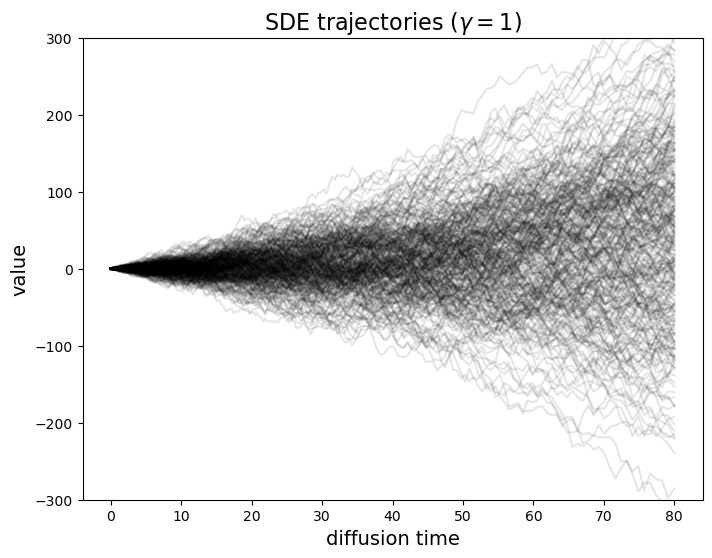

In [ ]:
sde_history = generate_samples(initial_step, gamma, nsteps, nsamples, dataset, sample_type='sde',
                               noisescheduler=scheduler, scheduler_type = process,
                               prior_perturbation=prior_perturbation)

In [58]:
ode_samples = ode_history[-1]
sde_samples = sde_history[-1]
# truncate samples at absolute value = 10
ode_samples = ode_samples[torch.abs(ode_samples)<10]
sde_samples = sde_samples[torch.abs(sde_samples)<10]
ode_samples.shape, sde_samples.shape

(torch.Size([99584]), torch.Size([99487]))

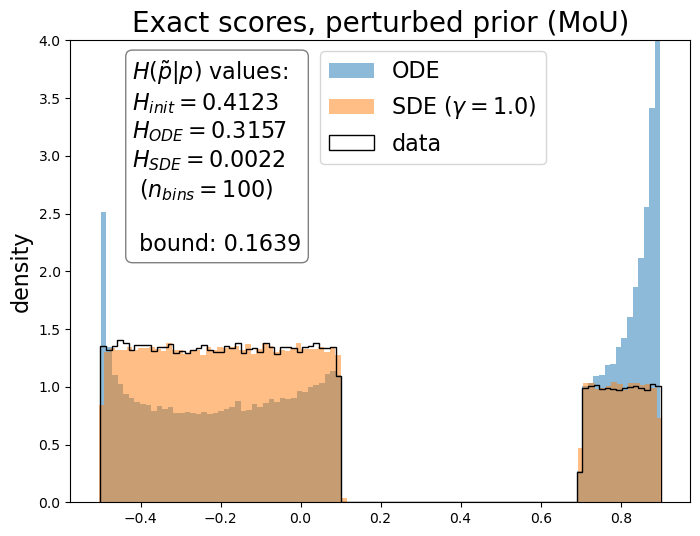

In [60]:
nbins = 100
plot_figure(ode_samples, sde_samples, diffused_data, gamma, datatype = datatype,
            nbins=nbins, initial_entropy=exact_initial_entropy, bound=bound,
            title=f'Exact scores, perturbed prior ({data_label})', fontsize=16, ylim=4)

In [61]:
# temporarily change gamma to 1
scheduler.langevin_const = 1

history_steps = nsteps+1-initial_step
forw_sde_history = scheduler.propagate_forward(diffused_data.unsqueeze(-1), dataset.gradlogprob, nsteps, record_history=True, stochastic=True)
forw_sde_history = forw_sde_history.cpu()
forw_sde_his = forw_sde_history[:history_steps].squeeze(-1)
forw_sde_his = forw_sde_his.flip(0)
forw_sde_his[-1] = data[0]

# unchange gamma
scheduler.langevin_const = gamma

forw_ode_history = scheduler.propagate_forward(diffused_data.unsqueeze(-1), dataset.gradlogprob, nsteps, record_history=True, stochastic=False)
forw_ode_history = forw_ode_history.cpu()
forw_ode_his = forw_ode_history[:history_steps].squeeze(-1)
forw_ode_his = forw_ode_his.flip(0)
forw_ode_his[-1] = data[0]
forw_sde_his.shape, forw_ode_his.shape

(torch.Size([501, 100000]), torch.Size([501, 100000]))

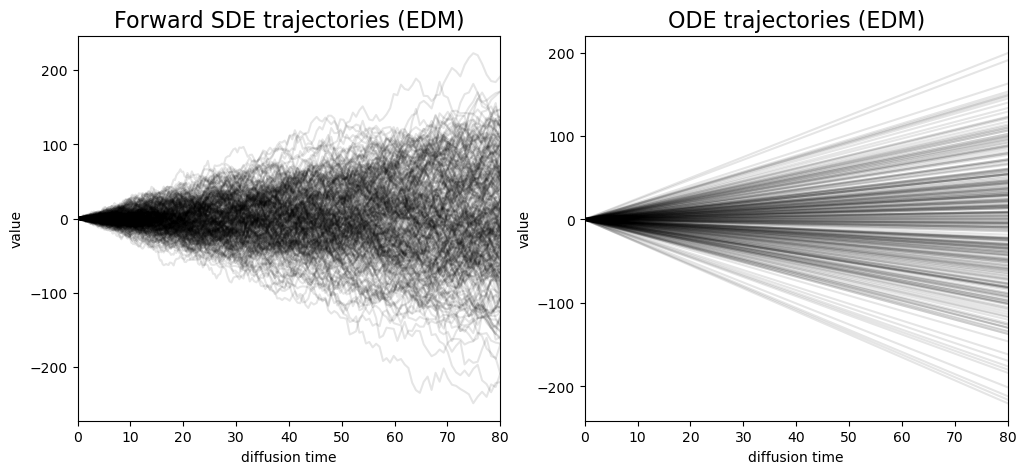

In [62]:
# plot forward trajectories
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
time2 = time[initial_step:]
nplot = 300
for i in range(nplot):
    x_sde = forw_sde_his[:, i].squeeze()
    x_ode = forw_ode_his[:, i].squeeze()
    axs[0].plot(time2, x_sde, color='black', linestyle='-', alpha=0.1)
    axs[1].plot(time2, x_ode, color='black', linestyle='-', alpha=0.1)
axs[0].set_title(f'Forward SDE trajectories ({process.upper()})', fontsize=16)
axs[1].set_title(f'ODE trajectories ({process.upper()})', fontsize=16)
for ax in axs:
    # ax.set_ylim([-3, 3])
    ax.set_xlim([0, initial_time])
    ax.set_xlabel("diffusion time")
    ax.set_ylabel("value")

In [63]:
# generate bounds
time2 = time[initial_step:]
bound_history = []
for t_i in time2:
    tau = float((time2[0] - t_i).item())
    integral, error = compute_integral(0.0, tau, initial_time, m, p, sigma_data, radius)
    decay = np.exp(-integral)
    bound = decay * exact_initial_entropy
    bound_history.append(bound)

/tmp/ipykernel_185035/3546880101.py:619: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  result, error = integrate.quad(


In [64]:
# eliminate outliers
threshold = 10

ode_history = ode_history[:, abs(ode_history[-1]) <= threshold]
sde_history = sde_history[:, abs(sde_history[-1]) <= threshold]

In [68]:
nbins = 50
inv_H = True
ode_entropies, sde_entropies = compute_entropy_evolution(
    ode_history[:-1], sde_history[:-1], forw_sde_his[:-1], time2[:-1],
    mean=True, nbins=nbins, inverseH=inv_H)

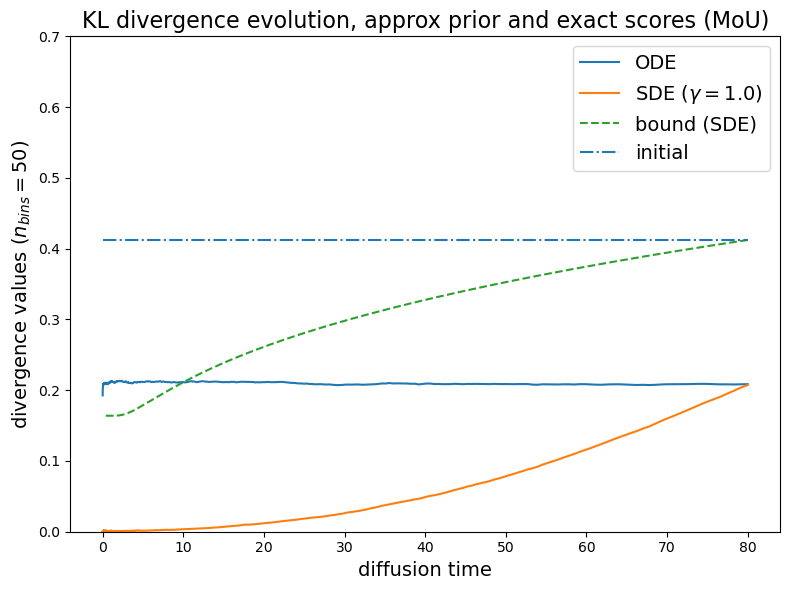

In [69]:
plot_entropy_evolution(ode_entropies, sde_entropies, time2[:-1], gamma, initial_time,
                       nbins=nbins, initial_entropy=exact_initial_entropy, bound_history=bound_history[:-1],
                       title=f' approx prior and exact scores ({data_label})', x_logscale=False, y_logscale=False, ylim=0.7)

In [70]:
# save bound history and sde entropies
if not os.path.exists('exact_scores'):
    os.makedirs('exact_scores')
np.save(f'exact_scores/bound_history-{datatype}.npy', bound_history)
if inv_H:
    np.save(f'exact_scores/sde_entropies-{datatype}-invH.npy', sde_entropies)
else:
    np.save(f'exact_scores/sde_entropies-{datatype}.npy', sde_entropies)

In [71]:
# load histories
sde_entropies = np.load(f'exact_scores/sde_entropies-gaussian2.npy')
bound_history = np.load(f'exact_scores/bound_history-gaussian2.npy')
sde_entropies2 = np.load(f'exact_scores/sde_entropies-uniform.npy')
bound_history2 = np.load(f'exact_scores/bound_history-uniform.npy')

/tmp/ipykernel_185035/3546880101.py:360: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, ylim)


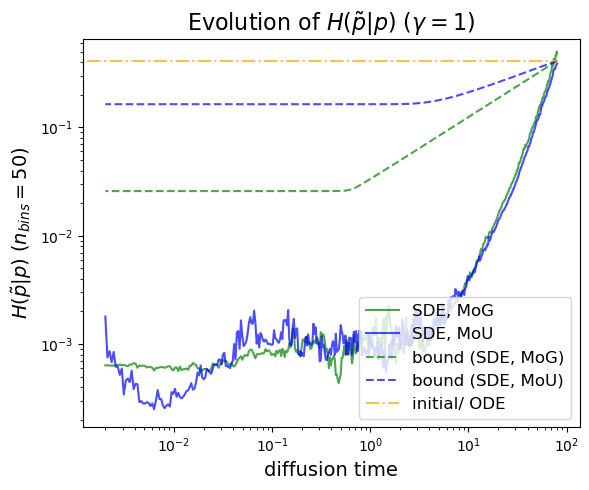

In [72]:
plot_entropy_evolution2(sde_entropies, sde_entropies2, 'SDE, MoG', 'SDE, MoU',
                        time2[:-1], gamma, initial_time, bound_history[:-1], bound_history2[:-1],
                        initial_entropy=exact_initial_entropy, nbins=nbins, ylim=0.65, y_logscale=True, x_logscale=True)

/tmp/ipykernel_185035/3546880101.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  s = torch.tensor(sigma*scale)


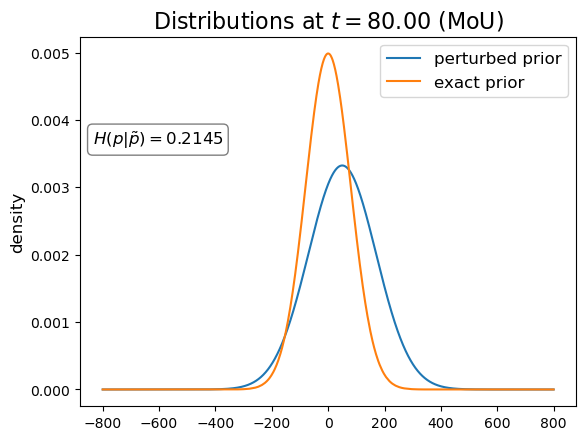

In [76]:
sigma = scheduler.scheduler_fns.noise_fn(initial_time_)
xlim = 10*sigma
exact_initial_entropy_invH = analytical_initial_entropy(
    dataset, initial_time, scheduler=scheduler, plot=True, xlim=xlim, data_label=data_label,
    fontsize=12, prior_perturbation=prior_perturbation, inverseH=True)

<>:5: SyntaxWarning: invalid escape sequence '\~'
<>:5: SyntaxWarning: invalid escape sequence '\~'
/tmp/ipykernel_185035/898928419.py:5: SyntaxWarning: invalid escape sequence '\~'
  time2[:-1], gamma, initial_time, entropy_name='$H(p|\~p)$',
/tmp/ipykernel_185035/3546880101.py:360: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, ylim)


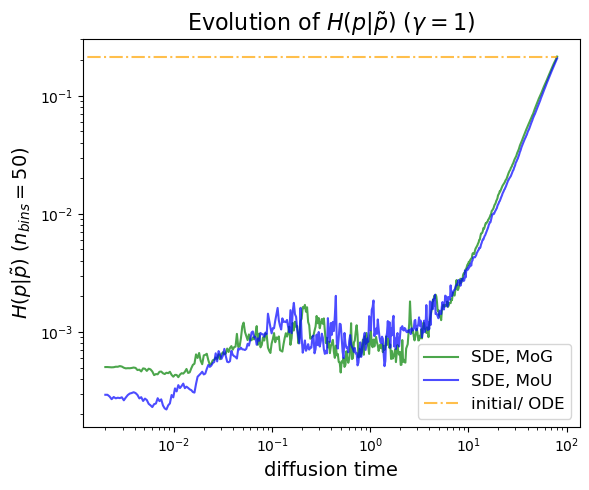

In [77]:
sde_entropies_invH = np.load(f'exact_scores/sde_entropies-gaussian2-invH.npy')
sde_entropies2_invH = np.load(f'exact_scores/sde_entropies-uniform-invH.npy')

plot_entropy_evolution2(sde_entropies_invH, sde_entropies2_invH, 'SDE, MoG', 'SDE, MoU',
                        time2[:-1], gamma, initial_time, entropy_name='$H(p|\~p)$',
                        initial_entropy=exact_initial_entropy_invH, nbins=nbins,
                        ylim=0.3, x_logscale=True, y_logscale=True)

## Discretization vs gamma

In [78]:
# Define parameters
process = 'edm'

if process == 'edm':
    scheduler = diffsci.models.EDMScheduler()
    initial_time=80
    # scheduler = diffsci.models.EDMScheduler(sigma_max=10.0)
    # initial_time=0.75
elif process == 'vp':
    # scheduler = VPScheduler(sigma_max=20)
    scheduler = VPScheduler()
    initial_time=0.21
elif process == 've':
    scheduler = VEScheduler()
    initial_time=0.55
else:
    raise ValueError('Invalid process')

initial_time_ = torch.tensor(initial_time)
nsteps = 500
gamma = 1
nsamples = 100000

initial_step = scheduler.step_from_time(t=initial_time_, n=nsteps)
time = scheduler.create_steps(nsteps+1)
initial_time = time[initial_step].item()
print(f'Initial step: {initial_step}')
print(f'Initial_time: {initial_time}')

Initial step: 0
Initial_time: 80.00001525878906


In [79]:
# # Generate data for comparison
tmin = time[-1]
print(f'Final time: {tmin}')
sigma_min = scheduler.scheduler_fns.noise_fn(tmin)
scale_min = scheduler.scheduler_fns.scaling_fn(tmin)
noise = torch.randn_like(uniform_samples) * sigma_min * scale_min

diffused_uniform_data = scale_min * uniform_samples + noise
diffused_uniform_data = diffused_uniform_data.squeeze(-1)
diffused_gaussian_data = scale_min * gaussian_samples2 + noise
diffused_gaussian_data = diffused_gaussian_data.squeeze(-1)

Final time: 0.0


In [80]:
sigma = scheduler.scheduler_fns.noise_fn(initial_time_)

# choose dataset
datatype = 'uniform'

if datatype == 'gaussian':
    diffused_data = diffused_gaussian_data
    dataset = gaussian_dataset2
    datatype = 'gaussian2'
    data = gaussian_samples2
    xlim = 6*sigma
    
elif datatype == 'uniform':
    diffused_data = diffused_uniform_data
    dataset = uniform_dataset
    data = uniform_samples
    xlim = 5*sigma
else:
    raise ValueError('Invalid datatype')

/tmp/ipykernel_185035/3546880101.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  s = torch.tensor(sigma*scale)


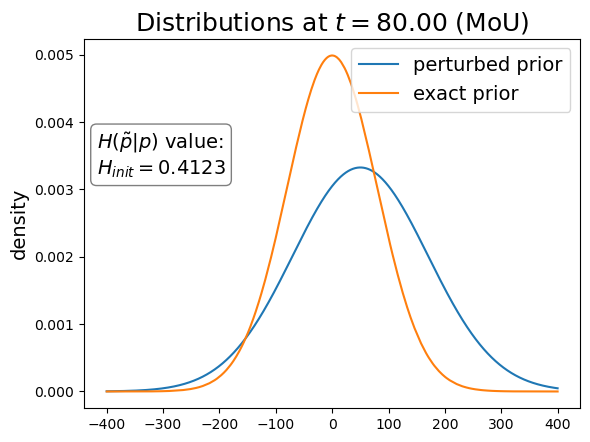

In [82]:
# gmax_unscaled = 0.2                # gmax will be gmax_unscaled * nsteps
gmax_unscaled = 0.2               # gmax will be gmax_unscaled * nsteps
gmin = 0.01
ngamma = 50
nsteps_values = [25, 50, 100, 200, 400]
# prior_perturbation = [20, 1.3]      # mean, std
prior_perturbation = [50, 1.5]      # mean, std

exact_initial_entropy = analytical_initial_entropy(
    dataset, initial_time, scheduler=scheduler, plot=True, xlim=xlim.item(), data_label=data_label,
    fontsize=14, prior_perturbation=prior_perturbation)

In [84]:
samples_list = []
for nsteps in nsteps_values:
    initial_step = scheduler.step_from_time(initial_time, nsteps)
    time = scheduler.create_steps(nsteps+1)
    gmax = gmax_unscaled * nsteps
    print(f"Sampling with nsteps={nsteps}")
    samples = generate_multiple_gamma(initial_step, [gmin, gmax], nsteps, nsamples, dataset,
                                      ngamma=ngamma, noisescheduler=scheduler, return_history=False,
                                      alpha=0.5, prior_perturbation=prior_perturbation)
    samples_list.append((samples, [gmin, gmax], ngamma, nsteps))

Sampling with nsteps=25
Sampling with nsteps=50
Sampling with nsteps=100
Sampling with nsteps=200
Sampling with nsteps=400


In [85]:
# truncate samples at absolute value = 10 (avoid outliers to corrupt entropy estimation)
def truncate_1d(x, max_abs=10):
    x_trunc = x[torch.abs(x) < max_abs]
    return x_trunc if x_trunc.numel() > 0 else x

truncated_samples_list = []
for samples, gamma_range, ngamma_, nsteps in samples_list:
    ode_samples, sde_samples = samples
    ode_samples = truncate_1d(ode_samples)
    sde_samples = [truncate_1d(s) for s in sde_samples]
    truncated_samples_list.append(([ode_samples, sde_samples], gamma_range, ngamma_, nsteps))
samples_list = truncated_samples_list
diffused_data_trunc = truncate_1d(diffused_data)

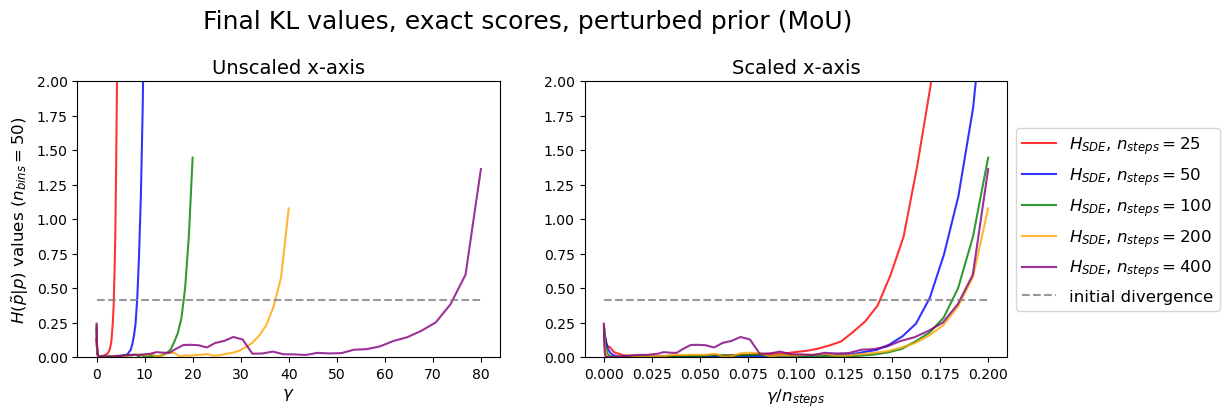

In [86]:
plot_multiple_gamma2(samples_list, diffused_data_trunc, initial_entropy=exact_initial_entropy, nbins=50,
                     title=f'Final KL values, exact scores, perturbed prior ({data_label})', alpha=0.5, fontsize=12, ylim=2)

In [17]:
# # plot some generated distributions
# gamma_indices = np.linspace(0, ngamma - 1, 5, dtype=int)

# for samples, gamma_range, ngamma_, nsteps in samples_list:
#     ode_samples, sde_samples = samples
#     gamma_values = custom_spacing(gamma_range[0], gamma_range[-1], ngamma_, alpha=0.5)

#     for idx in gamma_indices:
#         gamma = gamma_values[idx].item()
#         plot_figure(ode_samples, sde_samples[idx], diffused_data_trunc, nsamples, nsteps, gamma, initial_time,
#                     datatype=datatype, nbins=50, initial_entropy=exact_initial_entropy,
#                     title=f'Exact scores, perturbed prior ({process.upper()}), $n_{{steps}}={nsteps}$',
#                     figname=f'approx_prior-analytic-alpha=0.5-nsteps={nsteps}',
#                     fontsize=14, ylim=4)